# Model Comparison

Цель ноутбука:
- сравнить baseline-модель `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier`, `CatBoostClassifier`;
- использовать одинаковую подготовку данных и одинаковый train/test split;
- оценить модели по одинаковым метрикам;
- понять, дает ли дерево решений улучшение по сравнению с baseline.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

project_root = Path.cwd().resolve().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.churn.data import load_dataset
from src.churn.preprocessing import prepare_modeling_dataframe

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


ModuleNotFoundError: No module named 'catboost'

## Data Loading

Загружаем исходный датасет через функцию из `src/churn/data.py`.

Это позволяет убрать повторяющийся код из ноутбука и сделать проект более модульным.


In [ ]:
df = load_dataset()
df.shape


Dataset loaded from: ..\data\WA_Fn-UseC_-Telco-Customer-Churn.csv


## Feature Preparation

Используем ту же логику подготовки данных, что и в baseline-ноутбуке, через функцию из `src/churn/preprocessing.py`.

На этом этапе:
- создается числовая версия `TotalCharges`;
- создается бинарная целевая переменная `Churn_binary`;
- исключается `customerID`;
- удаляются исходные текстовые колонки, которые больше не нужны;
- удаляются строки с некорректными значениями `TotalCharges`.


In [ ]:
df_model = prepare_modeling_dataframe(df)
df_model.shape


(7032, 20)

## Feature Matrix and Target

Разделяем данные на признаки `X` и целевую переменную `y`.


In [ ]:
X = df_model.drop(columns=["Churn_binary"])
y = df_model["Churn_binary"]

X.shape, y.shape


((7032, 19), (7032,))

## Train/Test Split

Используем тот же принцип разделения данных:
- `test_size=0.2`
- `random_state=42`
- `stratify=y`

Это позволяет сохранить баланс классов и сделать сравнение моделей воспроизводимым.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape


((5625, 19), (1407, 19))

## Feature Types

Определяем числовые и категориальные признаки для preprocessing.


In [ ]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features


(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges_num'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

## Preprocessing Pipeline

Используем единый preprocessing pipeline:
- median imputation + scaling для числовых признаков;
- most frequent imputation + one-hot encoding для категориальных признаков.

Для честного сравнения моделей preprocessing должен быть одинаковым.


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges_num']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## Model 1: Logistic Regression

Сначала обучаем `LogisticRegression`, чтобы использовать ее как baseline для сравнения.


In [ ]:
logreg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

logreg_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges_num']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred_logreg = logreg_model.predict(X_test)
y_proba_logreg = logreg_model.predict_proba(X_test)[:, 1]


In [ ]:
logreg_metrics = {
    "model": "LogisticRegression",
    "roc_auc": roc_auc_score(y_test, y_proba_logreg),
    "pr_auc": average_precision_score(y_test, y_proba_logreg),
    "precision": precision_score(y_test, y_pred_logreg),
    "recall": recall_score(y_test, y_pred_logreg),
    "f1": f1_score(y_test, y_pred_logreg),
}

logreg_metrics


{'model': 'LogisticRegression',
 'roc_auc': np.float64(0.8351344145860403),
 'pr_auc': np.float64(0.6183128860330439),
 'precision': np.float64(0.4901315789473684),
 'recall': np.float64(0.7967914438502673),
 'f1': np.float64(0.6069246435845214)}

## Model 2: Decision Tree

Теперь обучаем `DecisionTreeClassifier` и сравниваем его с baseline-моделью.

На первом шаге используем простую версию дерева без сложной настройки, чтобы получить честное baseline-сравнение.


In [ ]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)

tree_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges_num']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [ ]:
y_pred_tree = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]


In [ ]:
tree_metrics = {
    "model": "DecisionTree",
    "roc_auc": roc_auc_score(y_test, y_proba_tree),
    "pr_auc": average_precision_score(y_test, y_proba_tree),
    "precision": precision_score(y_test, y_pred_tree),
    "recall": recall_score(y_test, y_pred_tree),
    "f1": f1_score(y_test, y_pred_tree),
}

tree_metrics


{'model': 'DecisionTree',
 'roc_auc': np.float64(0.6564546438129947),
 'pr_auc': np.float64(0.37963537561449134),
 'precision': np.float64(0.493368700265252),
 'recall': np.float64(0.49732620320855614),
 'f1': np.float64(0.49533954727030627)}

## Model 3: Random Forest

Теперь сравним baseline с `RandomForestClassifier`.

`RandomForest` является ансамблем деревьев решений и обычно работает устойчивее, чем одно отдельное дерево. Поэтому интересно проверить, даст ли он прирост качества по сравнению с `DecisionTreeClassifier` и `LogisticRegression`.


In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_estimators=200)),
    ]
)

rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges_num']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]


In [ ]:
rf_metrics = {
    "model": "RandomForest",
    "roc_auc": roc_auc_score(y_test, y_proba_rf),
    "pr_auc": average_precision_score(y_test, y_proba_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
}

rf_metrics


{'model': 'RandomForest',
 'roc_auc': np.float64(0.8139989957084653),
 'pr_auc': np.float64(0.5953830198762254),
 'precision': np.float64(0.6344827586206897),
 'recall': np.float64(0.4919786096256685),
 'f1': np.float64(0.5542168674698795)}

## Data Preparation for CatBoost

`CatBoostClassifier` умеет работать с категориальными признаками напрямую, поэтому для него не требуется one-hot encoding. Используем те же train/test данные, но передаем список категориальных колонок отдельно.


In [ ]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

cat_features_cb = categorical_features.copy()

X_train_cb.shape, X_test_cb.shape, cat_features_cb


((5625, 19),
 (1407, 19),
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

## Model 4: CatBoost

Теперь сравним baseline с `CatBoostClassifier` — сильной моделью для табличных данных, которая хорошо работает с категориальными признаками.


In [ ]:
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    eval_metric="AUC",
    loss_function="Logloss",
    random_state=42,
    verbose=False,
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features_cb,
)


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=False)

In [ ]:
y_pred_cb = catboost_model.predict(X_test_cb)
y_proba_cb = catboost_model.predict_proba(X_test_cb)[:, 1]


In [ ]:
catboost_metrics = {
    "model": "CatBoost",
    "roc_auc": roc_auc_score(y_test, y_proba_cb),
    "pr_auc": average_precision_score(y_test, y_proba_cb),
    "precision": precision_score(y_test, y_pred_cb),
    "recall": recall_score(y_test, y_pred_cb),
    "f1": f1_score(y_test, y_pred_cb),
}

catboost_metrics


{'model': 'CatBoost',
 'roc_auc': np.float64(0.8302643771580619),
 'pr_auc': np.float64(0.6446827649252608),
 'precision': np.float64(0.6456140350877193),
 'recall': np.float64(0.4919786096256685),
 'f1': np.float64(0.5584218512898331)}

In [ ]:
comparison_df = pd.DataFrame(
    [logreg_metrics, tree_metrics, rf_metrics, catboost_metrics]
)
comparison_df


,model,roc_auc,pr_auc,precision,recall,f1
0,LogisticRegression,0.835134,0.618313,0.490132,0.796791,0.606925
1,DecisionTree,0.656455,0.379635,0.493369,0.497326,0.495340
2,RandomForest,0.813999,0.595383,0.634483,0.491979,0.554217
3,CatBoost,0.830264,0.644683,0.645614,0.491979,0.558422


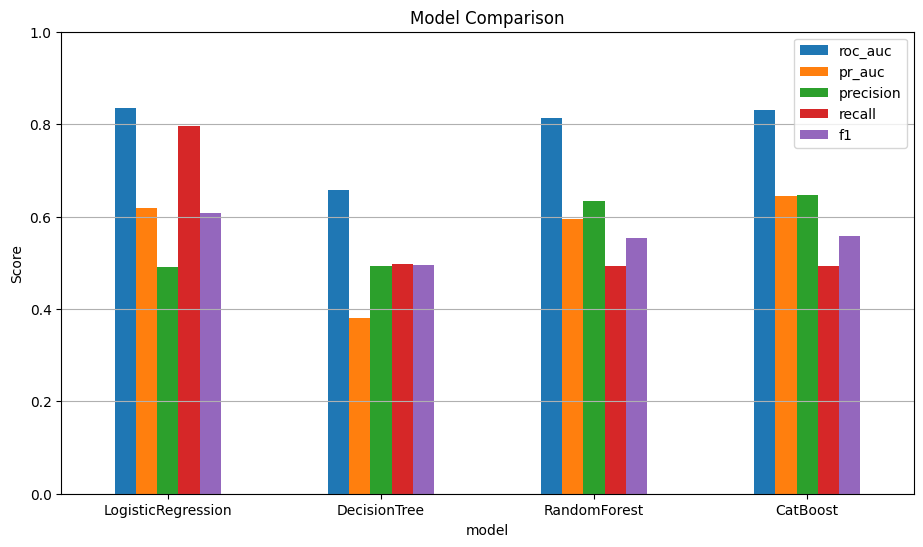

In [ ]:
comparison_plot = comparison_df.set_index("model")

comparison_plot[["roc_auc", "pr_auc", "precision", "recall", "f1"]].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


## Final Comparison Summary

В ноутбуке были сравнены четыре модели:
- `LogisticRegression`
- `DecisionTreeClassifier`
- `RandomForestClassifier`
- `CatBoostClassifier`

Результаты показали, что `LogisticRegression` остается лучшей моделью по совокупности baseline-метрик. Она показала лучшие значения `ROC-AUC`, `recall` и `f1-score`, что делает ее сильным кандидатом для сценария, где важно находить как можно больше клиентов с риском churn.

`CatBoostClassifier` показал лучший `PR-AUC` и лучший `precision`, что делает его наиболее интересной моделью в сценарии, где важно уменьшить число ложных срабатываний и точнее выделять клиентов с высоким риском оттока.

`RandomForestClassifier` показал результаты ниже `CatBoost` и не превзошел `LogisticRegression` по ключевым метрикам. `DecisionTreeClassifier` оказался самой слабой моделью среди рассмотренных.

Таким образом:
- `LogisticRegression` можно считать лучшей baseline-моделью по общей сбалансированности;
- `CatBoost` является сильным альтернативным кандидатом и может быть предпочтителен при фокусе на `precision` и `PR-AUC`;
- дальнейшее развитие проекта логично строить вокруг сравнения `LogisticRegression` и `CatBoost`.
